# 07 Progression Prediction Models

## Purpose
Train stronger models for multimorbidity progression among patients who are not already multimorbid at baseline.

## Imports

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"
MODELS_DIR = PROJECT_ROOT / "models"
for directory in [FIGURES_DIR, TABLES_DIR, MODELS_DIR, DATA_DIR / "processed"]:
    directory.mkdir(parents=True, exist_ok=True)

import pandas as pd
from sklearn.model_selection import train_test_split

from src.data_cleaning import load_raw_data, clean_all
from src.features import build_patient_features, get_modeling_matrices
from src.modeling import make_baseline_models, make_advanced_models, fit_models, save_model
from src.evaluation import evaluate_models, save_metrics, plot_roc_curves, plot_confusion_matrix
from src.visualization import plot_feature_importance

## Data loading

In [2]:
feature_path = DATA_DIR / "processed" / "modeling_dataset.csv"
if feature_path.exists():
    feature_df = pd.read_csv(feature_path)
else:
    data = clean_all(load_raw_data(DATA_DIR))
    feature_df = build_patient_features(**data)
    feature_df.to_csv(feature_path, index=False)

at_risk_df = feature_df[feature_df["baseline_condition_count"] < 2].copy()
at_risk_df.shape, at_risk_df["multimorbidity_progression"].mean()

((41654, 99), np.float64(0.43470014884524893))

## Main modeling

In [3]:
target = "multimorbidity_progression"
X, y = get_modeling_matrices(at_risk_df, target)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

models = {}
models.update(make_baseline_models(X_train))
models.update(make_advanced_models(X_train, random_state=42))

fitted_models = fit_models(models, X_train, y_train)
progression_metrics = evaluate_models(fitted_models, X_test, y_test, target)
progression_metrics

/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountere

/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,model,target,accuracy,precision,recall,f1,roc_auc,average_precision
2,random_forest,multimorbidity_progression,0.781160,0.715243,0.825050,0.766232,0.860540,0.761737
1,logistic_regression,multimorbidity_progression,0.768581,0.695692,0.831235,0.757448,0.853368,0.764152
0,dummy_most_frequent,multimorbidity_progression,0.565297,0.000000,0.000000,0.000000,0.500000,0.434703


/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


(<Figure size 500x400 with 1 Axes>,
 <Axes: title={'center': 'Best Progression Model Confusion Matrix: random_forest'}, xlabel='Predicted label', ylabel='True label'>)

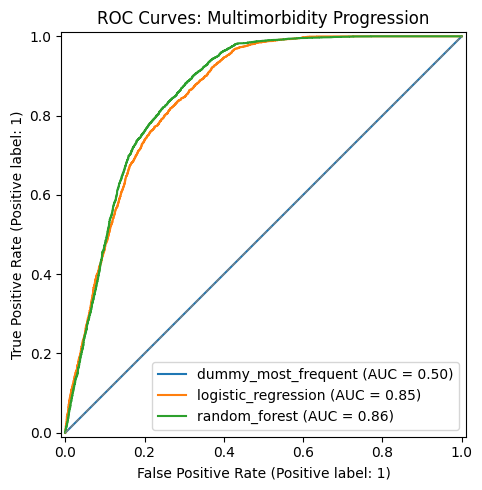

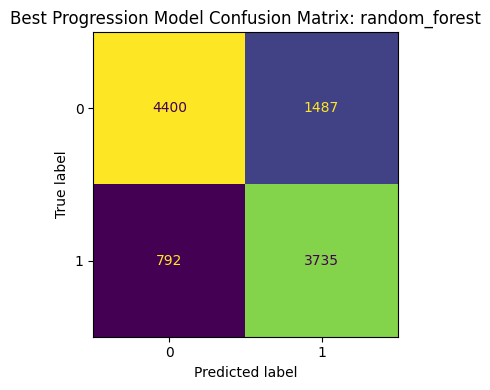

In [4]:
save_metrics(progression_metrics, TABLES_DIR / "07_progression_model_metrics.csv")
for name, model in fitted_models.items():
    save_model(model, MODELS_DIR / f"{target}_{name}.joblib")

plot_roc_curves(
    fitted_models, X_test, y_test,
    title="ROC Curves: Multimorbidity Progression",
    path=FIGURES_DIR / "07_progression_roc_curves.png",
)
best_name = progression_metrics.iloc[0]["model"]
plot_confusion_matrix(
    fitted_models[best_name], X_test, y_test,
    title=f"Best Progression Model Confusion Matrix: {best_name}",
    path=FIGURES_DIR / "07_best_progression_confusion_matrix.png",
)

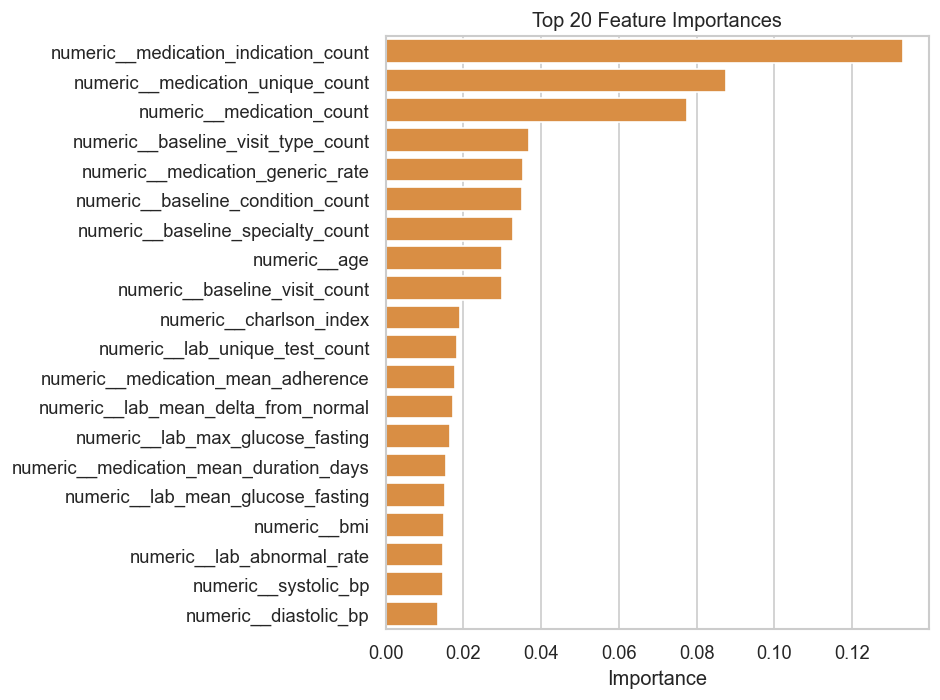

In [5]:
# Feature importance is available for tree-based models such as random forest, XGBoost, and LightGBM.
for candidate in ["lightgbm", "xgboost", "random_forest"]:
    if candidate in fitted_models:
        fig, ax, importance = plot_feature_importance(
            fitted_models[candidate],
            top_n=20,
            path=FIGURES_DIR / f"07_{candidate}_feature_importance.png",
        )
        importance.to_csv(TABLES_DIR / f"07_{candidate}_feature_importance.csv", index=False)
        break

## Key findings

- This notebook focuses on patients with fewer than two baseline conditions, because they are the clinically meaningful cohort for progression into multimorbidity.
- Advanced models are compared against the dummy and logistic baselines.
- Feature importance provides an interpretable first look at drivers of predicted progression.

## Saved outputs

Metrics, model artifacts, ROC curves, confusion matrix, and feature importance are saved for the final report.